<a href="https://colab.research.google.com/github/gnoejh/ict1022/blob/main/Neuralnets/mlp.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Multilayer Perceptron (MLP)

The Multilayer Perceptron (MLP) is the foundational architecture for modern neural networks. It consists of multiple layers of artificial neurons (perceptrons) that can approximate complex functions and learn patterns in data.

## Historical Context

The story of MLPs began with the simple perceptron model introduced by Frank Rosenblatt in 1958. However, as Minsky and Papert demonstrated in 1969, single-layer perceptrons couldn't solve linearly inseparable problems (like XOR). This limitation was overcome with the introduction of:

1. Multiple layers of perceptrons (hidden layers)
2. Non-linear activation functions
3. The backpropagation algorithm for training (popularized in the 1980s)

These innovations form the basis of what we now call the Multilayer Perceptron.

## Architecture

An MLP architecture typically consists of:

1. **Input Layer**: Neurons corresponding to features in the input data
2. **Hidden Layer(s)**: One or more layers that perform non-linear transformations
3. **Output Layer**: Produces the final prediction/classification

![MLP Architecture](https://upload.wikimedia.org/wikipedia/commons/thumb/4/46/Colored_neural_network.svg/300px-Colored_neural_network.svg.png)

Each connection between neurons has an associated weight, and each neuron typically has a bias term. The output of each neuron is computed as:

$$y = \sigma\left(\sum_{i=1}^{n} w_i x_i + b\right)$$

Where:
- $\sigma$ is a non-linear activation function
- $w_i$ are the weights
- $x_i$ are the inputs
- $b$ is the bias term

## Activation Functions

Common activation functions used in MLPs include:

1. **Sigmoid**: $\sigma(x) = \frac{1}{1 + e^{-x}}$
2. **Tanh**: $\tanh(x) = \frac{e^x - e^{-x}}{e^x + e^{-x}}$
3. **ReLU (Rectified Linear Unit)**: $f(x) = \max(0, x)$
4. **Leaky ReLU**: $f(x) = \max(\alpha x, x)$ where $\alpha$ is a small constant
5. **Softmax**: $\sigma(z)_i = \frac{e^{z_i}}{\sum_{j=1}^{K} e^{z_j}}$ (for output layer in classification tasks)

Let's visualize some of these activation functions:

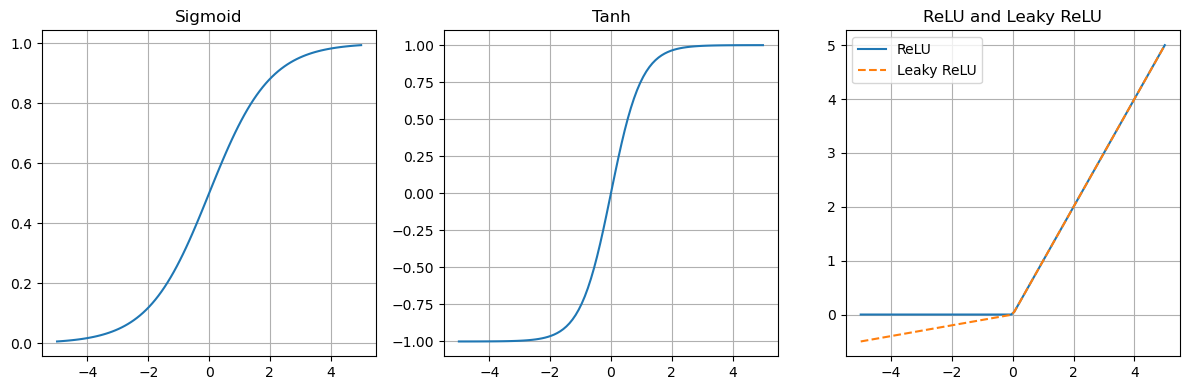

In [11]:
import numpy as np
import matplotlib.pyplot as plt

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def relu(x):
    return np.maximum(0, x)

def leaky_relu(x, alpha=0.1):
    return np.maximum(alpha * x, x)

x = np.linspace(-5, 5, 100)
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.plot(x, sigmoid(x))
plt.title('Sigmoid')
plt.grid(True)

plt.subplot(1, 3, 2)
plt.plot(x, np.tanh(x))
plt.title('Tanh')
plt.grid(True)

plt.subplot(1, 3, 3)
plt.plot(x, relu(x), label='ReLU')
plt.plot(x, leaky_relu(x), '--', label='Leaky ReLU')
plt.title('ReLU and Leaky ReLU')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

## Training with Backpropagation

MLPs are trained using the backpropagation algorithm, which consists of two main phases:

1. **Forward Pass**: Input values are passed through the network to generate predictions
2. **Backward Pass**: Error is calculated and propagated backward through the network to adjust weights

The goal is to minimize a loss function (e.g., Mean Squared Error for regression, Cross-Entropy for classification) by updating weights using gradient descent:

$$w_{new} = w_{old} - \eta \frac{\partial L}{\partial w}$$

Where:
- $L$ is the loss function
- $\eta$ is the learning rate
- $\frac{\partial L}{\partial w}$ is the gradient of the loss with respect to the weight

## Implementation Using NumPy

Let's implement a simple MLP from scratch using NumPy:

In [12]:
import numpy as np

class MLP:
    def __init__(self, input_size, hidden_size, output_size, learning_rate=0.01):
        # Initialize weights with random values
        self.W1 = np.random.randn(input_size, hidden_size) * 0.01
        self.b1 = np.zeros((1, hidden_size))
        self.W2 = np.random.randn(hidden_size, output_size) * 0.01
        self.b2 = np.zeros((1, output_size))
        self.learning_rate = learning_rate
        
    def sigmoid(self, x):
        return 1 / (1 + np.exp(-x))
    
    def sigmoid_derivative(self, x):
        return x * (1 - x)
    
    def forward(self, X):
        # Forward pass through the network
        self.z1 = np.dot(X, self.W1) + self.b1
        self.a1 = self.sigmoid(self.z1)
        self.z2 = np.dot(self.a1, self.W2) + self.b2
        self.a2 = self.sigmoid(self.z2)
        return self.a2
    
    def backward(self, X, y, output):
        # Backward pass to update weights
        m = X.shape[0]
        
        # Calculate gradients
        dz2 = output - y
        dW2 = np.dot(self.a1.T, dz2) / m
        db2 = np.sum(dz2, axis=0, keepdims=True) / m
        
        da1 = np.dot(dz2, self.W2.T)
        dz1 = da1 * self.sigmoid_derivative(self.a1)
        dW1 = np.dot(X.T, dz1) / m
        db1 = np.sum(dz1, axis=0, keepdims=True) / m
        
        # Update weights
        self.W2 -= self.learning_rate * dW2
        self.b2 -= self.learning_rate * db2
        self.W1 -= self.learning_rate * dW1
        self.b1 -= self.learning_rate * db1
    
    def train(self, X, y, epochs=10000):
        for epoch in range(epochs):
            output = self.forward(X)
            self.backward(X, y, output)
            
            # Print loss every 1000 epochs
            if epoch % 1000 == 0:
                loss = np.mean(np.square(y - output))
                print(f"Epoch {epoch}, Loss: {loss:.4f}")
    
    def predict(self, X):
        return self.forward(X)

## Example: XOR Problem

Let's use our MLP implementation to solve the XOR problem, which cannot be solved by a single-layer perceptron:

In [13]:
# XOR inputs and outputs
X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
y = np.array([[0], [1], [1], [0]])

# Create and train the MLP
mlp = MLP(input_size=2, hidden_size=4, output_size=1, learning_rate=0.5)
mlp.train(X, y, epochs=10000)

# Test the trained model
predictions = mlp.predict(X)
print("\nPredictions:")
for i in range(len(X)):
    print(f"Input: {X[i]}, Target: {y[i][0]}, Prediction: {predictions[i][0]:.4f}, Rounded: {round(predictions[i][0])}")

Epoch 0, Loss: 0.2500
Epoch 1000, Loss: 0.2500
Epoch 2000, Loss: 0.2500
Epoch 3000, Loss: 0.2500
Epoch 4000, Loss: 0.2500
Epoch 5000, Loss: 0.2500
Epoch 6000, Loss: 0.2500
Epoch 7000, Loss: 0.2500
Epoch 8000, Loss: 0.2500
Epoch 9000, Loss: 0.2500

Predictions:
Input: [0 0], Target: 0, Prediction: 0.5000, Rounded: 0
Input: [0 1], Target: 1, Prediction: 0.5000, Rounded: 0
Input: [1 0], Target: 1, Prediction: 0.5000, Rounded: 1
Input: [1 1], Target: 0, Prediction: 0.5000, Rounded: 1


## Implementation Using Modern Frameworks

In practice, MLPs are typically implemented using deep learning frameworks. Here's how you can create an MLP using PyTorch and TensorFlow/Keras:

### PyTorch Implementation

In [14]:
import torch
import torch.nn as nn
import torch.optim as optim

# Define the model
class PyTorchMLP(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(PyTorchMLP, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.sigmoid = nn.Sigmoid()
        self.fc2 = nn.Linear(hidden_size, output_size)
        
    def forward(self, x):
        x = self.fc1(x)
        x = self.sigmoid(x)
        x = self.fc2(x)
        x = self.sigmoid(x)
        return x

# Create model, loss function, and optimizer
model = PyTorchMLP(input_size=2, hidden_size=4, output_size=1)
criterion = nn.MSELoss()
optimizer = optim.SGD(model.parameters(), lr=0.5)

# Convert data to PyTorch tensors
X_tensor = torch.FloatTensor(X)
y_tensor = torch.FloatTensor(y)

# Train the model
epochs = 10000
for epoch in range(epochs):
    # Forward pass
    outputs = model(X_tensor)
    loss = criterion(outputs, y_tensor)
    
    # Backward pass and optimize
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    # Print loss every 1000 epochs
    if epoch % 1000 == 0:
        print(f'Epoch {epoch}, Loss: {loss.item():.4f}')

# Test the model
with torch.no_grad():
    test_outputs = model(X_tensor)
    print("\nPyTorch Model Predictions:")
    for i in range(len(X)):
        print(f"Input: {X[i]}, Target: {y[i][0]}, Prediction: {test_outputs[i].item():.4f}, Rounded: {round(test_outputs[i].item())}")

Epoch 0, Loss: 0.2518
Epoch 1000, Loss: 0.2498
Epoch 2000, Loss: 0.2457
Epoch 3000, Loss: 0.0458
Epoch 4000, Loss: 0.0060
Epoch 5000, Loss: 0.0028
Epoch 6000, Loss: 0.0018
Epoch 7000, Loss: 0.0013
Epoch 8000, Loss: 0.0010
Epoch 9000, Loss: 0.0009

PyTorch Model Predictions:
Input: [0 0], Target: 0, Prediction: 0.0191, Rounded: 0
Input: [0 1], Target: 1, Prediction: 0.9754, Rounded: 1
Input: [1 0], Target: 1, Prediction: 0.9685, Rounded: 1
Input: [1 1], Target: 0, Prediction: 0.0303, Rounded: 0


## Visualizing Decision Boundaries

Let's visualize how our MLP has learned to separate the XOR problem:

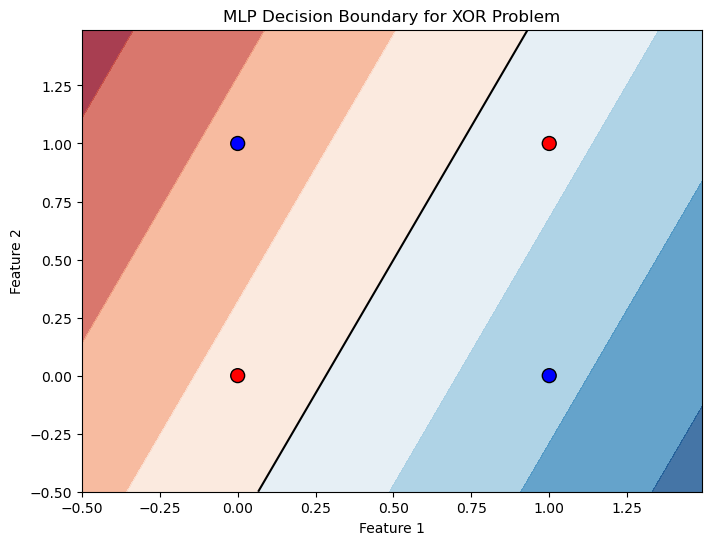

In [15]:
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import numpy as np

# Create a mesh grid
h = 0.01
x_min, x_max = -0.5, 1.5
y_min, y_max = -0.5, 1.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))

# Create input data for prediction
grid_points = np.c_[xx.ravel(), yy.ravel()]

# Get predictions from our model
Z = mlp.predict(grid_points)
Z = Z.reshape(xx.shape)

# Plot the decision boundary
plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, Z, cmap=plt.cm.RdBu, alpha=0.8)
plt.contour(xx, yy, Z, levels=[0.5], colors='k', linestyles='-')

# Plot the training points
plt.scatter(X[:, 0], X[:, 1], c=y.flatten(), cmap=ListedColormap(['red', 'blue']), edgecolors='k', s=100)

plt.xlim(xx.min(), xx.max())
plt.ylim(yy.min(), yy.max())
plt.title('MLP Decision Boundary for XOR Problem')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()

## Applications of MLPs

Multilayer Perceptrons have been applied to many problems including:

1. **Classification**: Handwritten digit recognition, spam detection, sentiment analysis
2. **Regression**: Price prediction, demand forecasting
3. **Pattern Recognition**: Speech recognition, image classification
4. **Function Approximation**: Modeling complex relationships between variables

Despite being largely superseded by more specialized architectures for specific tasks, MLPs remain a fundamental building block in many neural network designs and are often used as baseline models.

## Advantages and Limitations

### Advantages
- Universal function approximators (can approximate any continuous function)
- Simple to understand and implement
- Work well for tabular data with clear feature relationships
- Require relatively little preprocessing compared to other algorithms

### Limitations
- No spatial awareness (for images) or temporal awareness (for sequences)
- Prone to overfitting with limited data
- All neurons between layers must be connected, leading to many parameters
- Struggle with very high-dimensional data
- No built-in feature extraction capability

These limitations led to the development of specialized architectures like CNNs for images and RNNs/Transformers for sequential data.

## Further Reading

1. Rosenblatt, F. (1958). "The perceptron: A probabilistic model for information storage and organization in the brain." *Psychological Review*, 65(6), 386–408.
2. Rumelhart, D. E., Hinton, G. E., & Williams, R. J. (1986). "Learning representations by back-propagating errors." *Nature*, 323(6088), 533–536.
3. Hornik, K. (1991). "Approximation capabilities of multilayer feedforward networks." *Neural Networks*, 4(2), 251–257.
4. Goodfellow, I., Bengio, Y., & Courville, A. (2016). *Deep Learning*. MIT Press.